In [1]:
# !pip install lime


In [2]:
import os
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt

# Constants
train_folder = r'C:\Users\KIIT\Desktop\bone_fracture\train'
test_folder = r'C:\Users\KIIT\Desktop\bone_fracture\test'
IMG_SIZE = (128, 128)
RADIUS = 1
POINTS = 8
NUM_BINS = 16  # Number of bins for histogram

def load_data(directory):
    data = []
    labels = []
    label_names = sorted(os.listdir(directory))
    for label in label_names:
        class_dir = os.path.join(directory, label)
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, IMG_SIZE)
                data.append(img)  # Keep RGB image
                labels.append(label_names.index(label))
    return np.array(data), np.array(labels), label_names

# Load the dataset
train_data, train_labels, label_names = load_data(train_folder)
test_data, test_labels, _ = load_data(test_folder)

def calculate_lbp_for_channel(img_channel):
    lbp_img = local_binary_pattern(img_channel, POINTS, RADIUS, method='uniform')
    return lbp_img

def calculate_ldp_for_channel(img_channel):
    gradients = [cv2.Sobel(img_channel, cv2.CV_64F, 1, 0, ksize=3), cv2.Sobel(img_channel, cv2.CV_64F, 0, 1, ksize=3)]
    directions = np.arctan2(gradients[1], gradients[0]) * 180 / np.pi
    ldp_img = np.zeros_like(img_channel)
    for angle in [0, 45, 90, 135]:
        pattern = (directions >= angle - 22.5) & (directions < angle + 22.5)
        ldp_img += pattern.astype(np.uint8)
    return ldp_img

def extract_features(data):
    features = []
    for img in data:
        # Convert image to HSV color space
        hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Split HSV channels
        h, s, v = cv2.split(hsv_img)

        # Calculate LBP and LDP for each channel
        lbp_h = calculate_lbp_for_channel(h)
        lbp_s = calculate_lbp_for_channel(s)
        lbp_v = calculate_lbp_for_channel(v)

        ldp_h = calculate_ldp_for_channel(h)
        ldp_s = calculate_ldp_for_channel(s)
        ldp_v = calculate_ldp_for_channel(v)

        # Calculate histograms
        lbp_hist_h, _ = np.histogram(lbp_h, bins=NUM_BINS, range=(0, NUM_BINS))
        lbp_hist_s, _ = np.histogram(lbp_s, bins=NUM_BINS, range=(0, NUM_BINS))
        lbp_hist_v, _ = np.histogram(lbp_v, bins=NUM_BINS, range=(0, NUM_BINS))

        ldp_hist_h, _ = np.histogram(ldp_h, bins=NUM_BINS, range=(0, NUM_BINS))
        ldp_hist_s, _ = np.histogram(ldp_s, bins=NUM_BINS, range=(0, NUM_BINS))
        ldp_hist_v, _ = np.histogram(ldp_v, bins=NUM_BINS, range=(0, NUM_BINS))

        # Normalize histograms
        lbp_hist_h = lbp_hist_h.astype('float') / lbp_hist_h.sum()
        lbp_hist_s = lbp_hist_s.astype('float') / lbp_hist_s.sum()
        lbp_hist_v = lbp_hist_v.astype('float') / lbp_hist_v.sum()

        ldp_hist_h = ldp_hist_h.astype('float') / ldp_hist_h.sum()
        ldp_hist_s = ldp_hist_s.astype('float') / ldp_hist_s.sum()
        ldp_hist_v = ldp_hist_v.astype('float') / ldp_hist_v.sum()

        # Concatenate features
        features.append(np.concatenate((lbp_hist_h, lbp_hist_s, lbp_hist_v, ldp_hist_h, ldp_hist_s, ldp_hist_v)))

    return np.array(features)

# Extract features for train and test data
train_features = extract_features(train_data)
test_features = extract_features(test_data)

# Split data for training and testing
X_train, X_test, y_train, y_test = train_test_split(train_features, train_labels, test_size=0.2, random_state=42)

# Initialize the Random Forest classifier
rf_clf = RandomForestClassifier()

# Hyperparameter tuning using Grid Search
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}
grid_search = GridSearchCV(estimator=rf_clf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Get the best parameters and retrain the model
best_rf_clf = grid_search.best_estimator_
best_rf_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = best_rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Optimized Random Forest Accuracy: {accuracy:.2f}")



Fitting 3 folds for each of 216 candidates, totalling 648 fits
Optimized Random Forest Accuracy: 0.95


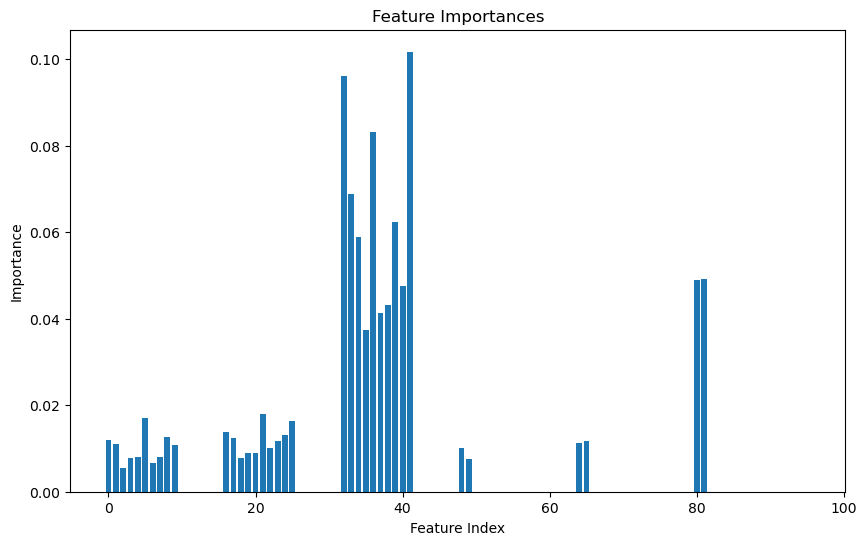

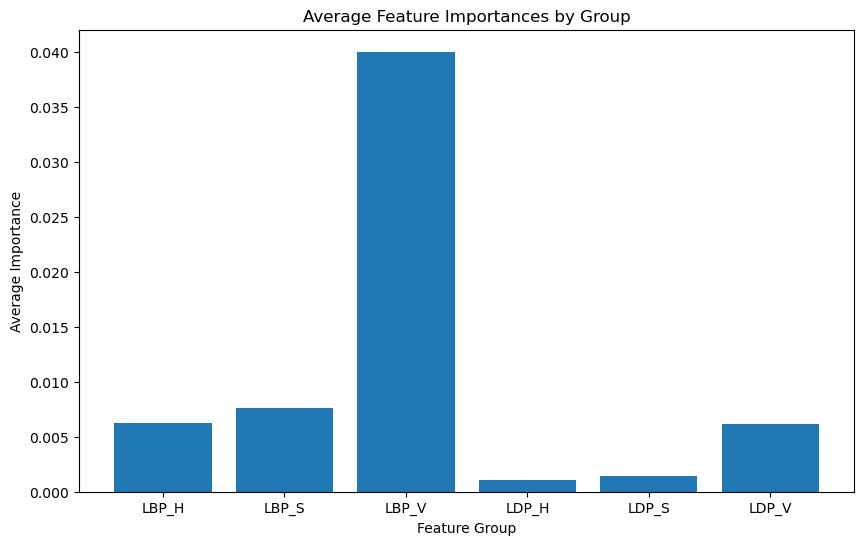

In [3]:
# Feature Importance Analysis
importances = best_rf_clf.feature_importances_

# Plot the feature importances
plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.show()

# Calculate the average importance for each group
num_bins = NUM_BINS  # Number of bins for histograms
groups = {
    'LBP_H': slice(0, num_bins),
    'LBP_S': slice(num_bins, 2*num_bins),
    'LBP_V': slice(2*num_bins, 3*num_bins),
    'LDP_H': slice(3*num_bins, 4*num_bins),
    'LDP_S': slice(4*num_bins, 5*num_bins),
    'LDP_V': slice(5*num_bins, 6*num_bins),
}

# Calculate the average importance for each group
group_importances = {k: np.mean(importances[v]) for k, v in groups.items()}

# Plot the group importances
plt.figure(figsize=(10, 6))
plt.bar(group_importances.keys(), group_importances.values())
plt.xlabel('Feature Group')
plt.ylabel('Average Importance')
plt.title('Average Feature Importances by Group')
plt.show()
